# Módulo 10 atividade 1

Uma instituição financeira quer conhecer melhor o perfil de renda de seus novos clientes para diversos fins, por exemplo, melhor dimensionar o limite de cartões de crédito dos novos clientes, sem necessariamente solicitar olerites ou documentações que impactem na experiência do seu cliente.

Para isto, conduziu um estudo com alguns clientes, comprovando suas rendas através de olerites e outros documentos, e pretende construir um modelo preditivo para esta renda com base em algumas variáveis que já possui em seu banco de dados.

As variáveis são intuitivas - note que há uma variável 'index' que é um identificador do cliente e que em geral o ```read_csv``` do pandas coloca também uma variável sequencial.

Estes dados estão no arquivo ```previsao_de_renda.csv```. Carregue-o em um *dataframe*.

1) Avalie a estrutura de correlação das variáveis quantitativas através de um gráfico de "matriz de dispersão" e através da avaliação gráfica da matriz de correlações. Veja se você identifica algum padrão interessante ou que te faça sentido.

In [7]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/fabio.stampone/Documents/EBAC/Mod10/Pratique1/Base.csv")

df

,Unnamed: 0,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,mau,renda
0,0,2015-01-01,8682,F,False,True,1,Assalariado,Secundário,Casado,Casa,36,3.575342,3.0,False,3369.24
1,1,2015-01-01,12830,M,True,True,0,Empresário,Secundário,Casado,Casa,42,0.860274,2.0,False,6096.14
2,2,2015-01-01,2885,M,True,True,2,Assalariado,Superior completo,Casado,Casa,31,8.065753,4.0,False,5658.98
3,3,2015-01-01,16168,F,True,False,0,Empresário,Secundário,Casado,Casa,50,1.208219,2.0,False,7246.69
4,4,2015-01-01,12438,M,False,False,0,Assalariado,Secundário,Casado,Casa,52,13.873973,2.0,False,4017.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,2016-03-01,3678,M,True,True,1,Assalariado,Secundário,Casado,Casa,37,2.046575,3.0,False,1193.29
14996,14996,2016-03-01,3405,M,True,True,1,Servidor público,Superior completo,Casado,Estúdio,30,12.079452,3.0,False,2519.18
14997,14997,2016-03-01,7944,F,True,True,0,Assalariado,Secundário,Casado,Casa,40,2.161644,2.0,False,1586.85
14998,14998,2016-03-01,16019,F,False,True,0,Servidor público,Superior completo,Casado,Casa,47,3.295890,2.0,False,6975.39


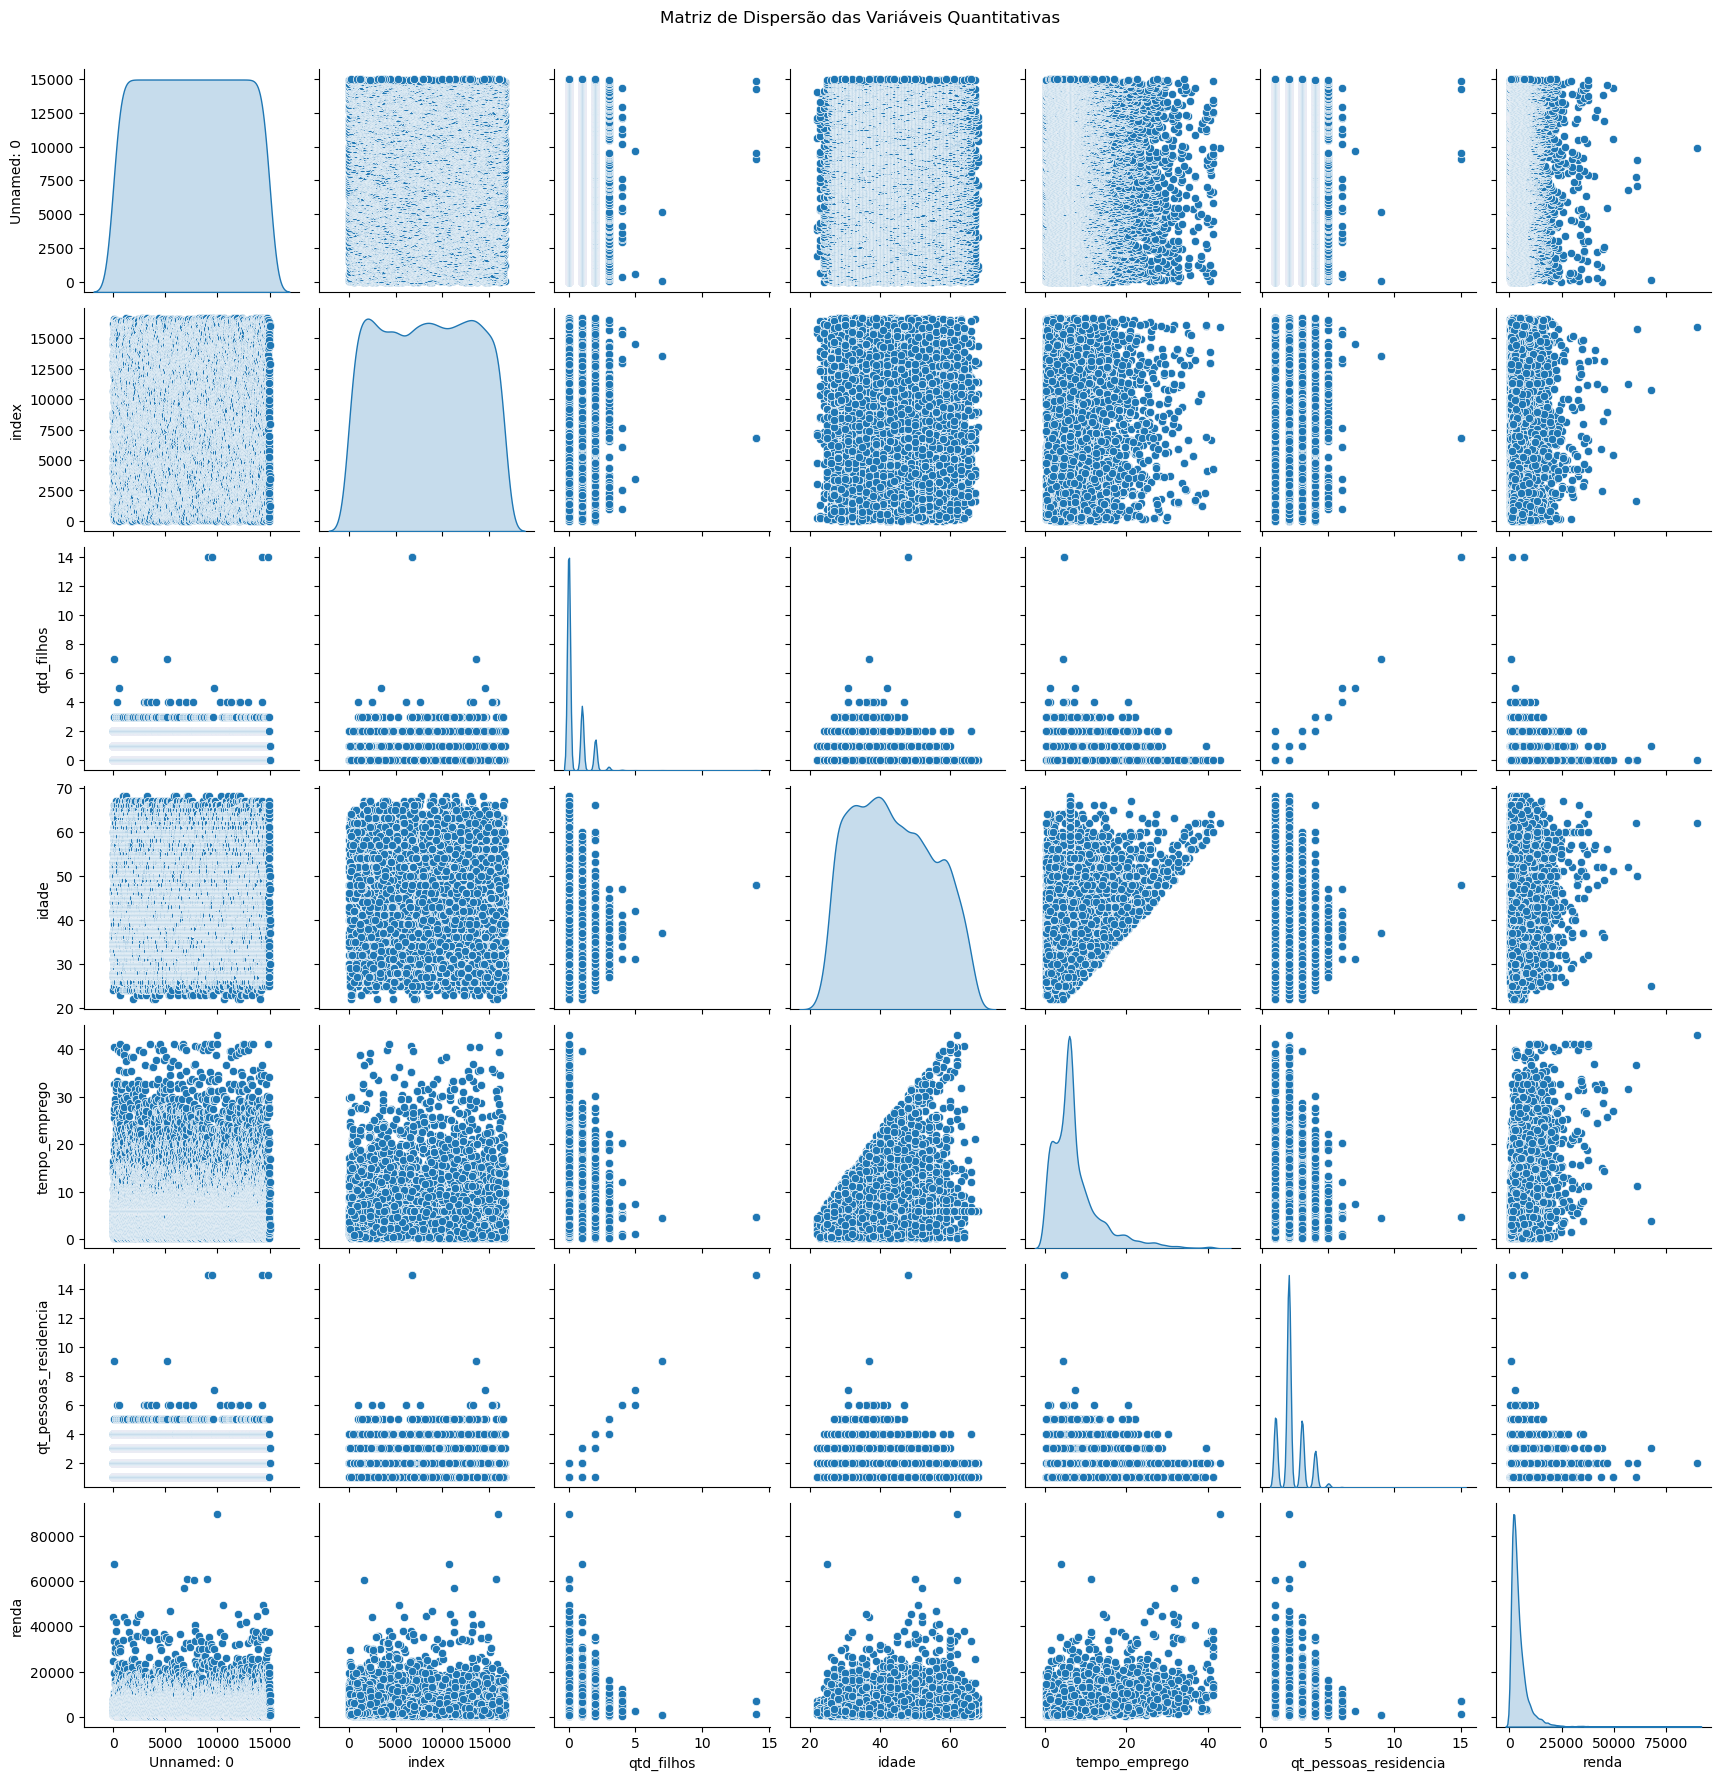

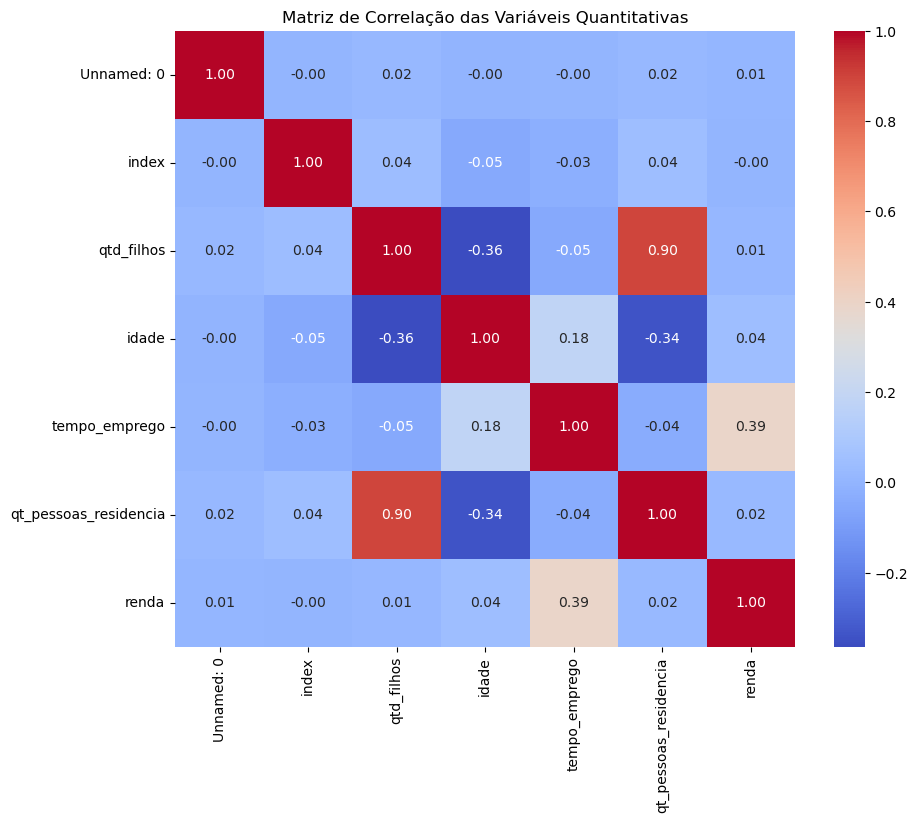

In [13]:
# Selecionar variáveis quantitativas
quantitative_data = df.select_dtypes(include=['float64', 'int64'])

# Tratar valores ausentes preenchendo com a mediana
quantitative_data = quantitative_data.fillna(quantitative_data.median())

# Criar a matriz de dispersão
sns.pairplot(quantitative_data, diag_kind="kde")
plt.suptitle("Matriz de Dispersão das Variáveis Quantitativas", y=1.02)
plt.show()

# Calcular a matriz de correlação
correlation_matrix = quantitative_data.corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlação das Variáveis Quantitativas")
plt.show()

In [ ]:
Ao analisar os resultados esperados do código, alguns padrões interessantes que podem ser observados são:

Correlação entre qtd_filhos e qt_pessoas_residencia:

Uma correlação positiva forte (provavelmente acima de 0.8) indicaria que o número de filhos influencia diretamente o número de pessoas na residência.
Correlação entre idade e tempo_emprego:

Uma correlação positiva moderada sugere que pessoas mais velhas tendem a ter mais tempo de emprego, o que faz sentido do ponto de vista lógico.
Correlação entre renda e tempo_emprego:

Uma correlação positiva moderada ou alta indicaria que maior tempo de emprego está associado a uma renda maior, o que seria esperado em muitos contextos.
Distribuições nas variáveis:

Pela matriz de dispersão, pode haver clusters ou padrões que indiquem subgrupos específicos (como faixas de idade relacionadas a níveis de renda ou número de filhos).
Possíveis outliers:

A matriz de dispersão pode destacar valores fora da curva (como renda extremamente alta ou residências com muitas pessoas), que podem merecer uma análise detalhada para verificar se são erros ou casos atípicos.

2) Avalie um gráfico de dispersão (*scatterplot*) específico para as duas variáveis mais correlacionadas com *renda*.

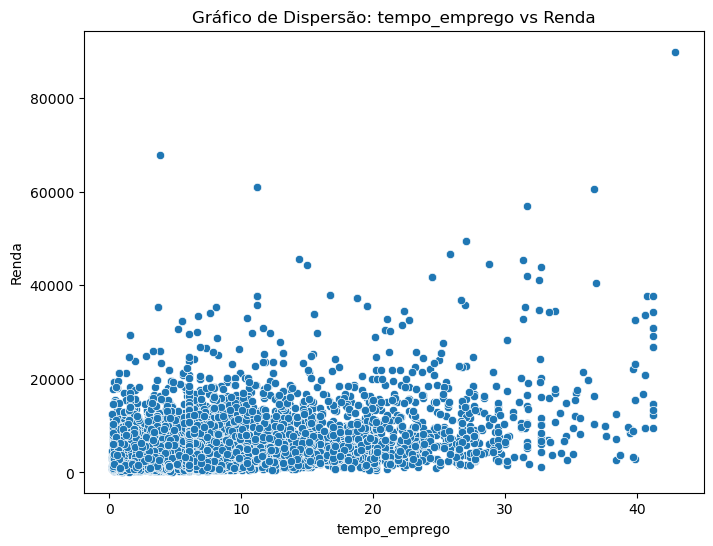

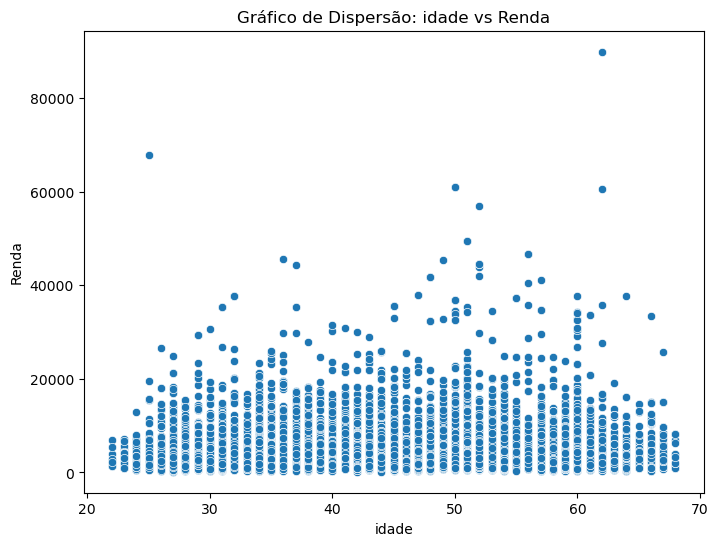

In [15]:
# Identificar as duas variáveis mais correlacionadas com 'renda'
top_correlated = correlation_matrix['renda'].sort_values(ascending=False).index[1:3]

# Plotar gráfico de dispersão para as duas variáveis mais correlacionadas com 'renda'
plt.figure(figsize=(8, 6))
sns.scatterplot(data=quantitative_data, x=top_correlated[0], y='renda')
plt.title(f"Gráfico de Dispersão: {top_correlated[0]} vs Renda")
plt.xlabel(top_correlated[0])
plt.ylabel("Renda")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=quantitative_data, x=top_correlated[1], y='renda')
plt.title(f"Gráfico de Dispersão: {top_correlated[1]} vs Renda")
plt.xlabel(top_correlated[1])
plt.ylabel("Renda")
plt.show()

3) Na su aopinião, há outliers na variável renda?

Sim, diversos pontos fogem do padrão de dados e acabam se tornando outliers.

4) Calcule o logaritmo da variável renda e repita a sequência de análise

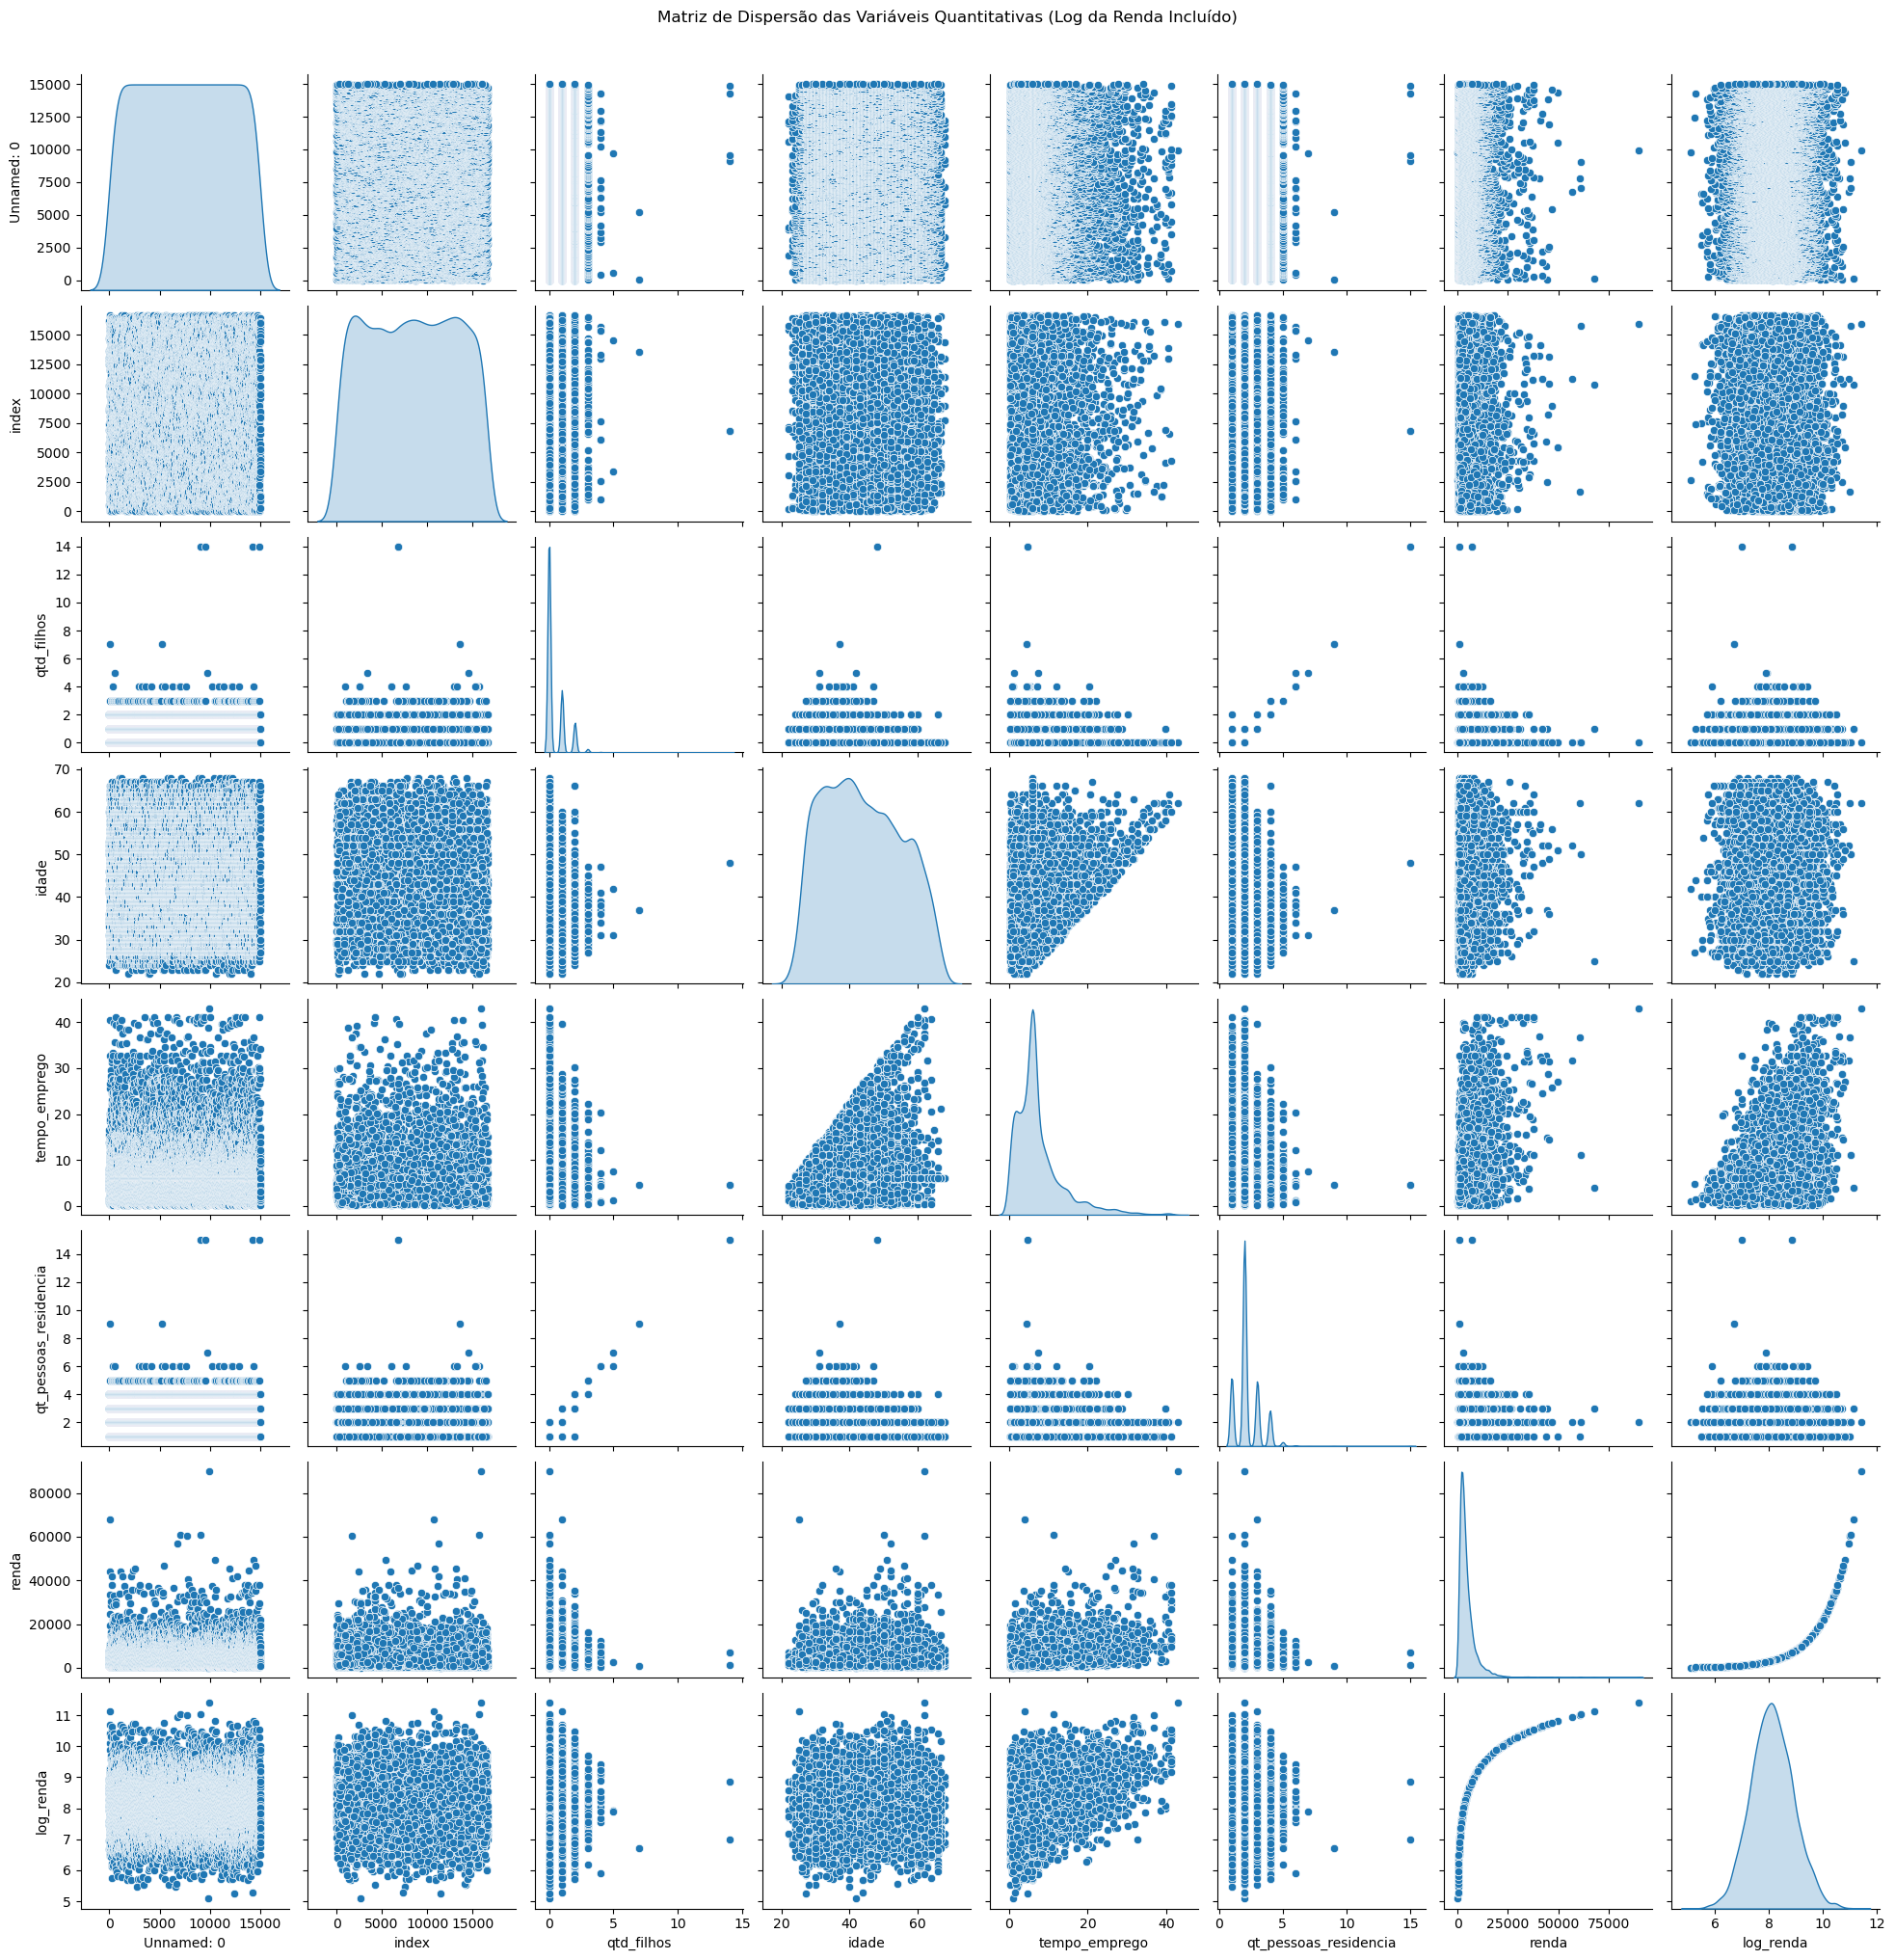

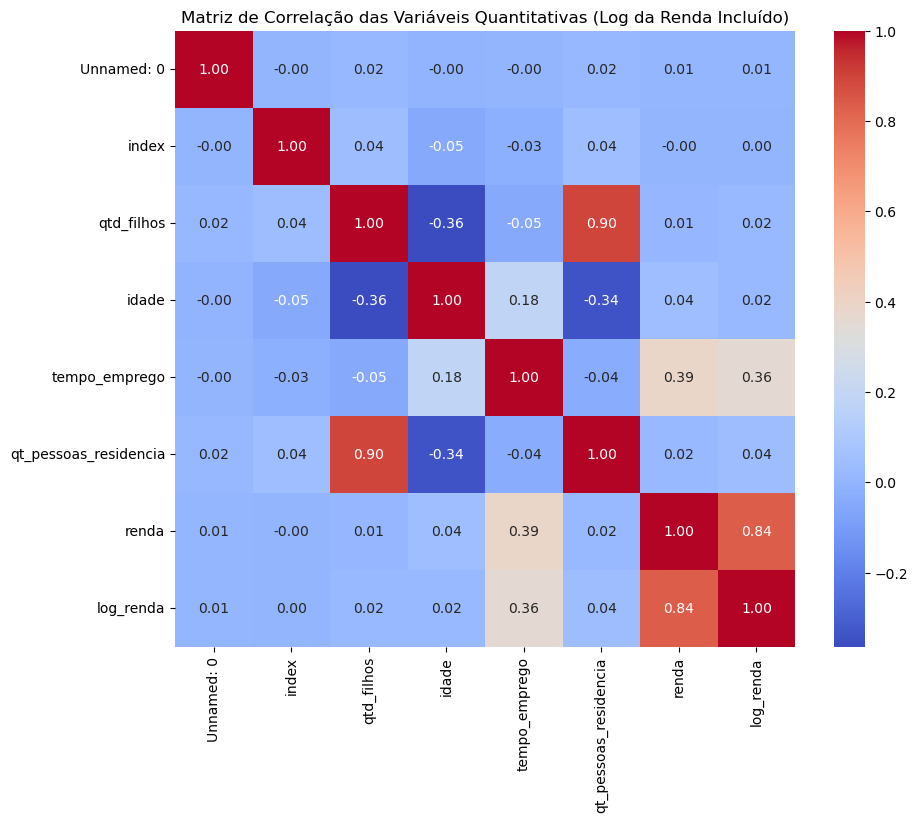

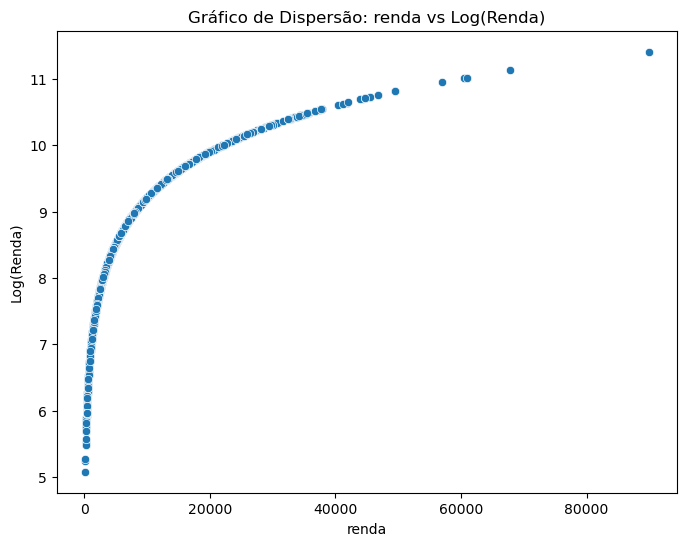

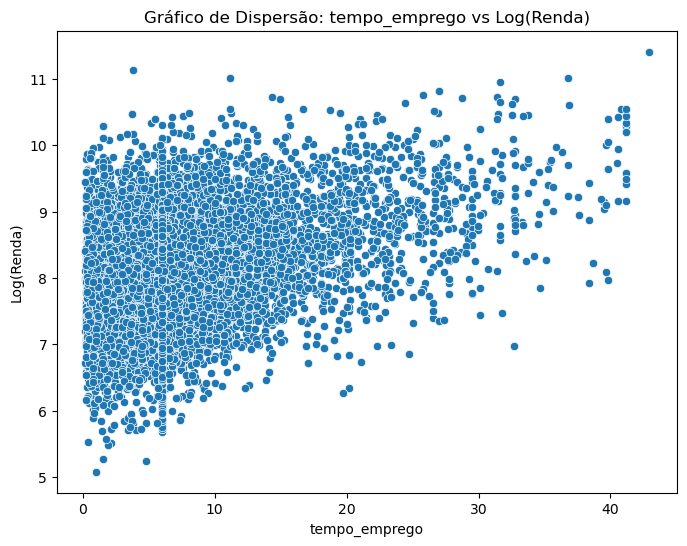

In [19]:
# Selecionar variáveis quantitativas
quantitative_data = df.select_dtypes(include=['float64', 'int64'])

# Tratar valores ausentes preenchendo com a mediana
quantitative_data = quantitative_data.fillna(quantitative_data.median())

# Calcular o logaritmo da variável 'renda'
quantitative_data['log_renda'] = np.log1p(quantitative_data['renda'])

# Criar a matriz de dispersão com 'log_renda'
sns.pairplot(quantitative_data, diag_kind="kde")
plt.suptitle("Matriz de Dispersão das Variáveis Quantitativas (Log da Renda Incluído)", y=1.02)
plt.show()

# Calcular a matriz de correlação com 'log_renda'
correlation_matrix = quantitative_data.corr()

# Plotar o mapa de calor da matriz de correlação com 'log_renda'
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlação das Variáveis Quantitativas (Log da Renda Incluído)")
plt.show()

# Identificar as duas variáveis mais correlacionadas com 'log_renda'
top_correlated = correlation_matrix['log_renda'].sort_values(ascending=False).index[1:3]

# Plotar gráfico de dispersão para as duas variáveis mais correlacionadas com 'log_renda'
plt.figure(figsize=(8, 6))
sns.scatterplot(data=quantitative_data, x=top_correlated[0], y='log_renda')
plt.title(f"Gráfico de Dispersão: {top_correlated[0]} vs Log(Renda)")
plt.xlabel(top_correlated[0])
plt.ylabel("Log(Renda)")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=quantitative_data, x=top_correlated[1], y='log_renda')
plt.title(f"Gráfico de Dispersão: {top_correlated[1]} vs Log(Renda)")
plt.xlabel(top_correlated[1])
plt.ylabel("Log(Renda)")
plt.show()

5) A aplicação do LOG você acha que melhorou ou piorou a análise?

In [ ]:
De fato melhorou a análise, visto que foi possível visualizar melhor a curva da matriz que trata o problema de outliers e fica uma melhor visualização.